# Módulo 1 — Case ao vivo: Modelo de Inadimplência de Assinatura

**Contexto:** uma empresa de assinaturas quer saber, todo mês, quais compradores vão deixar de pagar a próxima parcela — pra agir antes (lembrete, renegociação, oferta) em vez de só descobrir a inadimplência depois que ela já aconteceu.

Aqui a gente **não vai treinar nenhum modelo de verdade** — isso vem nos próximos módulos. Vamos só *simular* a base de compradores e a saída de dois modelos hipotéticos, pra poder discutir uma pergunta mais importante que "como construir o modelo": **como saber se um modelo é bom?**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

rng = np.random.default_rng(7)
N_COMPRADORES = 100

## 1. Simulando a base de compradores

Poucas features, de propósito — o objetivo não é discutir engenharia de features, só ter um cenário plausível:

- `qt_acessos_ultimo_mes`: quantas vezes o comprador acessou o produto no último mês (engajamento).
- `qt_parcelas_atrasadas`: quantas parcelas ele já atrasou até hoje (histórico de pagamento).
- `valor_parcela_prox_mes`: quanto ele precisa pagar mês que vem — fixo em R$1.000 pra todo mundo, pra simplificar a conta financeira mais adiante.
- `inadimplente`: a **resposta certa** — 1 se ele realmente vai deixar de pagar a próxima parcela, 0 se vai pagar.

In [2]:
qt_acessos_ultimo_mes = rng.poisson(lam=6, size=N_COMPRADORES)
qt_parcelas_atrasadas = rng.choice([0, 1, 2, 3, 4], size=N_COMPRADORES, p=[0.55, 0.20, 0.12, 0.08, 0.05])
valor_parcela_prox_mes = 1000.0

# relação real entre as features e o risco de inadimplência (a gente controla isso só pra simular;
# num caso real, é exatamente essa relação que um modelo tentaria aprender)
logit_risco_real = (
    -0.9
    - 0.12 * qt_acessos_ultimo_mes
    + 0.55 * qt_parcelas_atrasadas
    + rng.normal(0, 0.5, N_COMPRADORES)
)
prob_risco_real = 1 / (1 + np.exp(-logit_risco_real))
inadimplente = (rng.random(N_COMPRADORES) < prob_risco_real).astype(int)

compradores = pd.DataFrame({
    "comprador_id": range(1, N_COMPRADORES + 1),
    "qt_acessos_ultimo_mes": qt_acessos_ultimo_mes,
    "qt_parcelas_atrasadas": qt_parcelas_atrasadas,
    "valor_parcela_prox_mes": valor_parcela_prox_mes,
    "inadimplente": inadimplente,
})
compradores.head(10)

,comprador_id,qt_acessos_ultimo_mes,qt_parcelas_atrasadas,valor_parcela_prox_mes,inadimplente
0,1,6,1,"1,000.00",0
1,2,7,2,"1,000.00",0
2,3,8,1,"1,000.00",0
3,4,6,2,"1,000.00",0
4,5,2,1,"1,000.00",1
5,6,3,0,"1,000.00",0
6,7,8,1,"1,000.00",1
7,8,6,0,"1,000.00",1
8,9,8,0,"1,000.00",0
9,10,4,1,"1,000.00",0


In [ ]:
print(f"{inadimplente.sum()} de {N_COMPRADORES} compradores vão deixar de pagar a próxima parcela ({inadimplente.mean():.0%}).")

26 de 100 compradores vão deixar de pagar a próxima parcela (26%).


## 2. Simulando a saída de dois modelos (sem treinar nada)

- **Modelo 1 (conservador):** as probabilidades ficam bem próximas da média da base — ele quase nunca "aposta alto" que alguém vai atrasar.
- **Modelo 2 (agressivo):** as probabilidades se espalham bem mais — ele aponta risco alto com muito mais frequência.

Os dois usam o mesmo limiar pra decidir a classe prevista: probabilidade ≥ 50% → previsto como inadimplente.

In [4]:
prob_risco_medio = prob_risco_real.mean()

ruido_modelo_1 = rng.normal(0, 0.05, N_COMPRADORES)
ruido_modelo_2 = rng.normal(0, 0.08, N_COMPRADORES)

# quanto maior o fator, mais o modelo se afasta da média e "aposta" nos extremos
prob_inadimplencia_modelo_1 = np.clip(prob_risco_medio + 0.7 * (prob_risco_real - prob_risco_medio) + ruido_modelo_1, 0.01, 0.99)
prob_inadimplencia_modelo_2 = np.clip(prob_risco_medio + 4.0 * (prob_risco_real - prob_risco_medio) + ruido_modelo_2, 0.01, 0.99)

compradores["prob_inadimplencia_modelo_1"] = prob_inadimplencia_modelo_1
compradores["prob_inadimplencia_modelo_2"] = prob_inadimplencia_modelo_2
compradores["previsto_modelo_1"] = (prob_inadimplencia_modelo_1 >= 0.5).astype(int)
compradores["previsto_modelo_2"] = (prob_inadimplencia_modelo_2 >= 0.5).astype(int)

colunas_exibir = [
    "comprador_id", "qt_acessos_ultimo_mes", "qt_parcelas_atrasadas", "inadimplente",
    "prob_inadimplencia_modelo_1", "previsto_modelo_1", "prob_inadimplencia_modelo_2", "previsto_modelo_2",
]
compradores[colunas_exibir].head(10)

,comprador_id,qt_acessos_ultimo_mes,qt_parcelas_atrasadas,inadimplente,prob_inadimplencia_modelo_1,previsto_modelo_1,prob_inadimplencia_modelo_2,previsto_modelo_2
0,1,6,1,0,0.18,0,0.01,0
1,2,7,2,0,0.34,0,0.49,0
2,3,8,1,0,0.15,0,0.01,0
3,4,6,2,0,0.34,0,0.54,1
4,5,2,1,1,0.36,0,0.68,1
5,6,3,0,0,0.24,0,0.24,0
6,7,8,1,1,0.37,0,0.69,1
7,8,6,0,1,0.23,0,0.01,0
8,9,8,0,0,0.11,0,0.01,0
9,10,4,1,0,0.22,0,0.09,0


## 3. Métrica de ciência de dados: acurácia

A **matriz de confusão** cruza o que o modelo previu com o que realmente aconteceu:

- **TN** (verdadeiro negativo): previu que ia pagar, e pagou.
- **FP** (falso positivo): previu que ia atrasar, mas pagou.
- **FN** (falso negativo): previu que ia pagar, mas atrasou.
- **TP** (verdadeiro positivo): previu que ia atrasar, e atrasou.

A **acurácia** é a fração de previsões certas: `(TN + TP) / total`.

In [5]:
def matriz_confusao(previsto, real):
    TN = int(((previsto == 0) & (real == 0)).sum())
    FP = int(((previsto == 1) & (real == 0)).sum())
    FN = int(((previsto == 0) & (real == 1)).sum())
    TP = int(((previsto == 1) & (real == 1)).sum())
    return TN, FP, FN, TP


def acuracia(TN, FP, FN, TP):
    return (TN + TP) / (TN + FP + FN + TP)


TN1, FP1, FN1, TP1 = matriz_confusao(compradores["previsto_modelo_1"], compradores["inadimplente"])
TN2, FP2, FN2, TP2 = matriz_confusao(compradores["previsto_modelo_2"], compradores["inadimplente"])

resumo_acuracia = pd.DataFrame({
    "modelo": ["Modelo 1 (conservador)", "Modelo 2 (agressivo)"],
    "TN": [TN1, TN2], "FP": [FP1, FP2], "FN": [FN1, FN2], "TP": [TP1, TP2],
    "acuracia": [acuracia(TN1, FP1, FN1, TP1), acuracia(TN2, FP2, FN2, TP2)],
})
resumo_acuracia

,modelo,TN,FP,FN,TP,acuracia
0,Modelo 1 (conservador),73,1,24,2,0.75
1,Modelo 2 (agressivo),60,14,14,12,0.72


Pela acurácia, o **Modelo 1** parece o melhor — erra menos vezes no total. Mas essa métrica trata todo erro como igual, e não diz nada sobre **quanto cada acerto ou erro vale em R$**. Será que é essa a pergunta que o negócio quer responder?

## 4. Métrica de negócio: quanto isso vale em R$?

Pra cada comprador que o modelo aponta como risco (`previsto = 1`), a empresa age (ex.: liga, manda SMS, oferece renegociação). Essa ação tem um **custo por contato**, e só **recupera a parcela em parte das vezes** (taxa de recuperação) — mesmo ligando, nem todo mundo que ia atrasar acaba pagando.

- **TN**: não agimos, e ele paga normalmente → ganha a parcela inteira, sem custo.
- **FN**: não agimos, e ele atrasa → não ganha nada (e é o pior caso: nem a chance de agir a gente teve).
- **FP**: agimos à toa (ele ia pagar de qualquer jeito) → ganha a parcela, mas paga o custo do contato.
- **TP**: agimos e valeu a pena → recupera a parcela só na fração definida pela taxa de recuperação, e ainda paga o custo do contato.

Comparando com não fazer nada (deixar todo mundo pagar por conta própria), o **ganho** de usar o modelo é:

`ganho = TP × parcela × taxa_recuperação − custo_por_contato × (TP + FP)`

In [6]:
def ganho_financeiro(TP, FP, parcela, custo_por_contato, taxa_recuperacao):
    return TP * parcela * taxa_recuperacao - custo_por_contato * (TP + FP)


custo_por_contato = 1
taxa_recuperacao = 0.5

ganho_modelo_1 = ganho_financeiro(TP1, FP1, valor_parcela_prox_mes, custo_por_contato, taxa_recuperacao)
ganho_modelo_2 = ganho_financeiro(TP2, FP2, valor_parcela_prox_mes, custo_por_contato, taxa_recuperacao)

pd.DataFrame({
    "modelo": ["Modelo 1 (conservador)", "Modelo 2 (agressivo)"],
    "acuracia": [acuracia(TN1, FP1, FN1, TP1), acuracia(TN2, FP2, FN2, TP2)],
    "ganho_financeiro": [ganho_modelo_1, ganho_modelo_2],
})

,modelo,acuracia,ganho_financeiro
0,Modelo 1 (conservador),0.75,997.00
1,Modelo 2 (agressivo),0.72,"5,974.00"


Com custo de contato baixo, o **Modelo 2** — o mesmo que tinha acurácia pior — gera muito mais retorno: ele erra mais vezes no total, mas acerta muito mais gente que realmente ia atrasar, e cada acerto desses vale mais do que o custo de errar num falso positivo.

## 5. "O melhor modelo" depende do custo da ação

Isso muda se a ação de contato ficar mais cara. Vamos variar o `custo_por_contato` e recalcular o ganho dos dois modelos pra cada valor.

In [7]:
custos = np.arange(0, 301, 5)
ganhos = pd.DataFrame({
    "custo_por_contato": custos,
    "Modelo 1 (conservador)": [ganho_financeiro(TP1, FP1, valor_parcela_prox_mes, c, taxa_recuperacao) for c in custos],
    "Modelo 2 (agressivo)": [ganho_financeiro(TP2, FP2, valor_parcela_prox_mes, c, taxa_recuperacao) for c in custos],
})

diferenca = ganhos["Modelo 2 (agressivo)"] - ganhos["Modelo 1 (conservador)"]
custo_cruzamento = ganhos["custo_por_contato"][(diferenca >= 0).values.argmin()]
print(f"A partir de ~R$ {custo_cruzamento} por contato, o Modelo 1 volta a ganhar do Modelo 2.")
ganhos.head()

A partir de ~R$ 220 por contato, o Modelo 1 volta a ganhar do Modelo 2.


,custo_por_contato,Modelo 1 (conservador),Modelo 2 (agressivo)
0,0,"1,000.00","6,000.00"
1,5,985.00,"5,870.00"
2,10,970.00,"5,740.00"
3,15,955.00,"5,610.00"
4,20,940.00,"5,480.00"


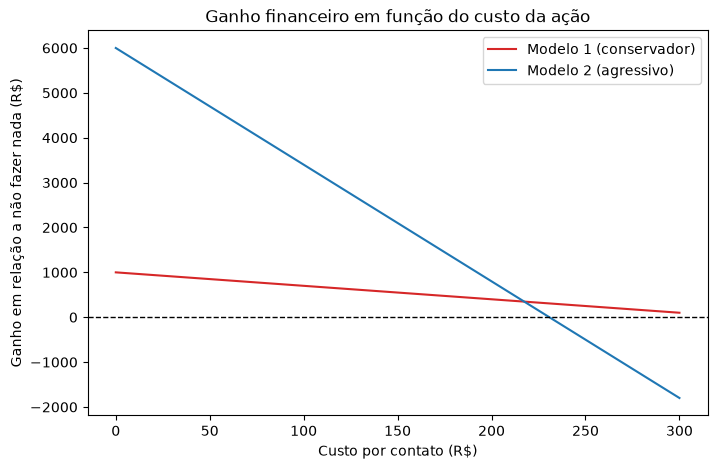

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ganhos["custo_por_contato"], ganhos["Modelo 1 (conservador)"], label="Modelo 1 (conservador)", color="tab:red")
ax.plot(ganhos["custo_por_contato"], ganhos["Modelo 2 (agressivo)"], label="Modelo 2 (agressivo)", color="tab:blue")
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Custo por contato (R$)")
ax.set_ylabel("Ganho em relação a não fazer nada (R$)")
ax.set_title("Ganho financeiro em função do custo da ação")
ax.legend()
plt.show()

## Pra levar

Não existe "o melhor modelo" fora de um contexto de negócio:

- A **acurácia** trata todo erro como igual — mas nem todo erro custa a mesma coisa.
- O **ganho financeiro** depende de quanto vale reter o cliente, quanto custa agir, e qual a chance real de recuperar a parcela.
- Mudando só o custo da ação, o modelo "vencedor" muda — sem que nada no modelo em si tenha mudado.

Esse é o fio condutor que vamos aprofundar ao longo da pós: dos próximos módulos em diante, vocês vão aprender a construir, treinar e validar modelos de verdade — mas a pergunta "essa métrica reflete o que o negócio precisa?" continua valendo em todos eles.